# **Autoencoder LSTM** — representación no supervisada para *sleep staging*

Los tres modelos anteriores (XGBoost tabular, LSTM inter-época, CNN 1D intra-época) son **supervisados**: aprenden un mapeo directo de la señal/features a la etiqueta del experto. Este cuaderno explora una pregunta distinta:

> **¿Una representación aprendida SIN etiquetas captura estructura útil para clasificar etapas del sueño, comparada con las features *handcrafted* del baseline?**

Para responderla entrenamos un **autoencoder secuencial (LSTM)** que aprende a *reconstruir* las secuencias de features por noche —sin ver nunca la etiqueta— y extraemos el vector del *bottleneck* como **embedding por época**. Después entrenamos un XGBoost sobre esos embeddings (mismo split y misma configuración que `baseline.ipynb`) y comparamos *apples-to-apples*.

El pipeline: **entrenar AE → extraer embeddings → XGBoost sobre embeddings → XGBoost sobre [handcrafted | embeddings]**.

## Arquitectura del autoencoder

$$
x[T, F] \;\xrightarrow{\text{Encoder BiLSTM}}\; h[T, 2H] \;\xrightarrow{\text{Linear}}\; z[T, L] \;\xrightarrow{\text{Decoder LSTM}}\; g[T, H] \;\xrightarrow{\text{Linear}}\; \hat{x}[T, F]
$$

- **Input** $x[T, F]$: una noche completa como secuencia de $T$ épocas ($T \approx 800\text{–}900$, variable), cada una con las $F=122$ features del `epoch_features.csv` (las mismas HRV / acelerometría / lags-leads / medias móviles que usa el baseline).
- **Encoder — BiLSTM**: lee la noche hacia adelante y hacia atrás, concatena los estados forward/backward por timestep ($2H$) y una capa lineal los proyecta al **bottleneck** $z_t \in \mathbb{R}^{L}$ ($L=32$). Ese $z_t$ es el **embedding de la época** $t$.
- **Decoder — LSTM (unidireccional)**: toma la secuencia de embeddings $z_t$ y reconstruye $\hat{x}_t$, la estimación de las features originales de cada época.
- **Output** $\hat{x}[T, F]$: la reconstrucción. El objetivo es que $\hat{x} \approx x$.

El *bottleneck* de dimensión baja ($122 \to 32$) obliga a la red a **comprimir** cada época —junto con su contexto temporal, que la recurrencia inyecta— en un vector del cual se pueda reconstruir la entrada. Si esa compresión conserva la información fisiológica relevante, un clasificador posterior debería poder leer las etapas de ahí.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("..")

## 1. Entrenamiento del autoencoder

`train(ConfigAE())` splitea por sujeto, entrena el AE minimizando la reconstrucción y guarda el mejor checkpoint por *val recon loss* en `../src/models/best_ae.pt`. Requiere el `epoch_features.csv` generado por `baseline.ipynb`.

In [2]:
from src.lstm_ae import ConfigAE, train, extract_embeddings

cfg = ConfigAE()
model, history = train(cfg)

sujetos -> train 33 | val 7 | test 7


entrenando AE: 100%|██████████| 60/60 [09:33<00:00,  9.56s/epoch, train_recon=0.0813, val_recon=0.2349, best=0.2313] 



TEST (mejor ckpt, val recon 0.2313, epoch 59):
  recon loss 0.0665


### Curva de reconstrucción

Train vs. validación. Si divergen, el AE estaría memorizando; si ambas bajan y se estabilizan juntas, la compresión generaliza.

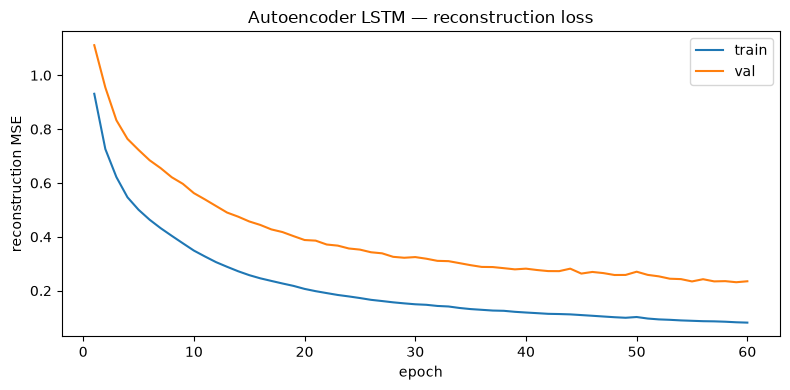

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

h = pd.DataFrame(history)
plt.figure(figsize=(8, 4))
plt.plot(h['epoch'], h['train_recon'], label='train')
plt.plot(h['epoch'], h['val_recon'], label='val')
plt.xlabel('epoch'); plt.ylabel('reconstruction MSE'); plt.legend(); plt.title('Autoencoder LSTM — reconstruction loss')
plt.tight_layout(); plt.show()

## 2. Extracción de embeddings

Con el mejor checkpoint congelado, se corre el **encoder** sobre todas las noches de todos los sujetos y se alinea cada $z_t$ con `(subject, night, epoch, label, dreem)`. Se guarda en `../data/ae_embeddings.parquet` (parquet: preserva tipos y carga rápido).

In [4]:
import torch

ckpt = torch.load(cfg.ckpt_path, map_location=cfg.device, weights_only=False)
emb = extract_embeddings(model, cfg, ckpt['mean'], ckpt['std'])
emb.head()

extrayendo embeddings: 100%|██████████| 251/251 [00:19<00:00, 12.77noche/s]


embeddings -> ../data/ae_embeddings.parquet  (210440 épocas, 32 dims)


,subject,night,epoch,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,...,emb_24,emb_25,emb_26,emb_27,emb_28,emb_29,emb_30,emb_31,label,dreem
0,0,1,0,-3.809950,-1.631964,-3.711254,0.795750,-2.221365,0.356160,0.944564,...,3.291418,-2.286336,-0.756020,-0.580856,2.578109,0.650393,1.903614,-1.112856,0,0
1,0,1,1,-2.781412,-0.989449,-2.178523,1.299674,-2.137080,-0.276210,0.480635,...,2.172463,-2.127241,-0.444652,-1.336791,1.708374,0.018315,1.712203,-1.496309,0,0
2,0,1,2,-2.347110,-0.346712,0.058353,0.731580,-2.024718,-0.239196,0.779180,...,1.736622,-2.249941,0.138804,-1.399214,2.078160,-0.413517,1.625204,-1.448256,0,0
3,0,1,3,-1.087541,-0.217965,-1.741548,1.241356,-0.964198,0.415110,0.968841,...,0.204943,-0.956566,-1.047753,-0.241276,1.245267,-0.775543,1.807991,-1.438694,0,0
4,0,1,4,-1.141114,-0.256361,0.123168,0.563718,-1.119625,-0.093927,0.665028,...,1.090666,-0.997868,0.249946,-1.114326,1.011570,-0.108839,1.016446,-0.472777,0,0


## 3. XGBoost sobre los embeddings

Reconstruimos el **mismo split por sujeto** que usó el AE (mismo `split_subjects` y semilla → sujetos idénticos, sin *leakage*) y entrenamos un XGBoost con la **misma configuración que `baseline.ipynb`**, pero usando como features únicamente las $L=32$ dimensiones aprendidas. Descartamos `label==5`.

In [ ]:
import numpy as np
from src.lstm import split_subjects

emb = pd.read_parquet(cfg.embeddings_path)
_, subj = split_subjects(emb, cfg)  # mismos sujetos train/val/test que el AE

emb_cols = [c for c in emb.columns if c.startswith('emb_')]

def split_xy(df_full, subj_set, feature_cols):
    d = df_full[df_full['subject'].isin(subj_set) & (df_full['label'] != 5)]
    return d[feature_cols], d['label'].values, d['dreem'].values

X_train, y_train, _ = split_xy(emb, subj['train'], emb_cols)
X_val, y_val, _ = split_xy(emb, subj['val'], emb_cols)
X_test, y_test, dreem_test = split_xy(emb, subj['test'], emb_cols)

print(f"épocas -> train: {len(X_train)}  val: {len(X_val)}  test: {len(X_test)}")

épocas -> train: 143389  val: 33634  test: 31465


In [6]:
from xgboost import XGBClassifier

def fit_xgb(X_train, y_train, X_val, y_val):
    clf = XGBClassifier(
        n_estimators=600,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='mlogloss',
        early_stopping_rounds=30,
        n_jobs=-1,
        random_state=42,
    )
    clf.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    print(f"mejor iteración (early stopping): {clf.best_iteration}")
    return clf

clf_emb = fit_xgb(X_train, y_train, X_val, y_val)

mejor iteración (early stopping): 503


### Métricas (idénticas a `baseline.ipynb`)

Mismas métricas que el baseline para comparación directa: Cohen's Kappa y F1-macro vs. *expert* (y vs. *dreem* como segunda anotación), `classification_report`, `confusion_matrix`, y la **versión colapsada a 4 clases** (Wake / Light=N1+N2 / Deep=N3 / REM) comparable con SLAMSS-IFS.

In [7]:
from sklearn.metrics import f1_score, cohen_kappa_score, classification_report, confusion_matrix

map4 = {0: 0, 1: 1, 2: 1, 3: 2, 4: 3}
names4 = ['Wake', 'Light', 'Deep', 'REM']
remap = np.vectorize(map4.get)

def report(clf, X_test, y_test, dreem_test):
    y_pred = clf.predict(X_test)

    # 5 clases -- vs Expert (target) y vs Dreem (2da anotación, descartando Unknown)
    kappa_exp = cohen_kappa_score(y_test, y_pred)
    f1_exp = f1_score(y_test, y_pred, average='macro')
    mask = dreem_test != 5
    kappa_dreem = cohen_kappa_score(dreem_test[mask], y_pred[mask])
    f1_dreem = f1_score(dreem_test[mask], y_pred[mask], average='macro')

    print(f"Expert  ->  F1-macro: {f1_exp:.3f}   Cohen's Kappa: {kappa_exp:.3f}")
    print(f"Dreem   ->  F1-macro: {f1_dreem:.3f}   Cohen's Kappa: {kappa_dreem:.3f}")
    print("\nReporte por clase (vs Expert):")
    print(classification_report(y_test, y_pred, target_names=['Wake', 'N1', 'N2', 'N3', 'REM']))
    print("Matriz de confusión (vs Expert):")
    print(confusion_matrix(y_test, y_pred, labels=range(5)))

    # 4 clases colapsadas (SLAMSS-IFS)
    y_test4, y_pred4 = remap(y_test), remap(y_pred)
    kappa_exp4 = cohen_kappa_score(y_test4, y_pred4)
    f1_exp4 = f1_score(y_test4, y_pred4, average='macro')
    print(f"\nExpert (4 clases)  ->  F1-macro: {f1_exp4:.3f}   Cohen's Kappa: {kappa_exp4:.3f}")
    print(classification_report(y_test4, y_pred4, target_names=names4))
    return y_pred

_ = report(clf_emb, X_test, y_test, dreem_test)

Expert  ->  F1-macro: 0.386   Cohen's Kappa: 0.272
Dreem   ->  F1-macro: 0.389   Cohen's Kappa: 0.279

Reporte por clase (vs Expert):
              precision    recall  f1-score   support

        Wake       0.53      0.40      0.46      3492
          N1       0.26      0.00      0.01      2940
          N2       0.53      0.55      0.54     12259
          N3       0.55      0.41      0.47      6030
         REM       0.36      0.62      0.45      6744

    accuracy                           0.47     31465
   macro avg       0.45      0.40      0.39     31465
weighted avg       0.47      0.47      0.45     31465

Matriz de confusión (vs Expert):
[[1409    7  584  486 1006]
 [ 272   10  900  265 1493]
 [ 410   11 6759 1084 3995]
 [ 370    3 2223 2481  953]
 [ 179    7 2234  171 4153]]

Expert (4 clases)  ->  F1-macro: 0.483   Cohen's Kappa: 0.274
              precision    recall  f1-score   support

        Wake       0.53      0.40      0.46      3492
       Light       0.60      0.

## 4. Variante: [features *handcrafted* | embeddings del AE]

El resultado más informativo para el póster: entrenamos el XGBoost sobre la **concatenación** de las features hechas a mano (baseline) con los embeddings aprendidos, mergeando por `(subject, night, epoch)`. La `feature_importance` revela **de dónde saca la señal** el modelo: si se apoya en las features handcrafted o si las dimensiones aprendidas por el AE aportan información complementaria.

In [8]:
feat = pd.read_csv("../data/epoch_features.csv")
meta_cols = ['subject', 'night', 'epoch', 'label', 'dreem']
hand_cols = [c for c in feat.columns if c not in meta_cols]

# merge por (subject, night, epoch); las etiquetas vienen de feat para no duplicarlas
merged = feat.merge(emb[['subject', 'night', 'epoch'] + emb_cols],
                    on=['subject', 'night', 'epoch'], how='inner')
combo_cols = hand_cols + emb_cols

Xc_train, yc_train, _           = split_xy(merged, subj['train'], combo_cols)
Xc_val,   yc_val,   _           = split_xy(merged, subj['val'],   combo_cols)
Xc_test,  yc_test,  dreemc_test = split_xy(merged, subj['test'],  combo_cols)

print(f"features -> handcrafted: {len(hand_cols)}  +  embeddings: {len(emb_cols)}  =  {len(combo_cols)}")
clf_combo = fit_xgb(Xc_train, yc_train, Xc_val, yc_val)
_ = report(clf_combo, Xc_test, yc_test, dreemc_test)

features -> handcrafted: 122  +  embeddings: 32  =  154
mejor iteración (early stopping): 154
Expert  ->  F1-macro: 0.447   Cohen's Kappa: 0.334
Dreem   ->  F1-macro: 0.446   Cohen's Kappa: 0.341

Reporte por clase (vs Expert):
              precision    recall  f1-score   support

        Wake       0.66      0.53      0.59      3492
          N1       0.27      0.01      0.03      2940
          N2       0.55      0.54      0.55     12259
          N3       0.67      0.56      0.61      6030
         REM       0.37      0.63      0.46      6744

    accuracy                           0.51     31465
   macro avg       0.50      0.45      0.45     31465
weighted avg       0.52      0.51      0.50     31465

Matriz de confusión (vs Expert):
[[1867   23  498  202  902]
 [ 284   40  908  210 1498]
 [ 333   23 6586 1152 4165]
 [ 287   12 1620 3384  727]
 [  69   50 2287  119 4219]]

Expert (4 clases)  ->  F1-macro: 0.554   Cohen's Kappa: 0.340
              precision    recall  f1-score   

### ¿De dónde saca la señal? (feature importance)

`importance_type='gain'` sobre el modelo combinado. Si entre las top features aparecen dims `emb_*`, el AE está aportando información que el modelo aprovecha por encima de (o en complemento a) las features handcrafted.

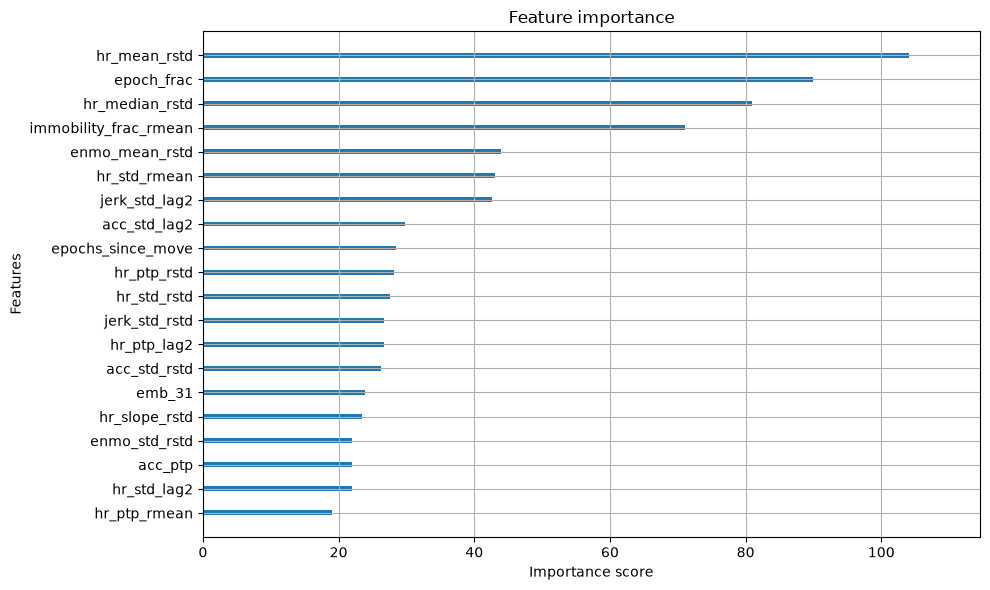

Ganancia aportada por embeddings del AE: 12.0% del total


In [9]:
from xgboost import plot_importance

_, ax = plt.subplots(1, 1, figsize=(10, 6))
plot_importance(clf_combo, ax=ax, importance_type='gain', max_num_features=20, show_values=False)
plt.tight_layout(); plt.show()

# fracción de la importancia total que aportan las dims aprendidas por el AE
imp = clf_combo.get_booster().get_score(importance_type='gain')
emb_gain = sum(v for k, v in imp.items() if k.startswith('emb_'))
total_gain = sum(imp.values())
print(f"Ganancia aportada por embeddings del AE: {emb_gain / total_gain:.1%} del total")